In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
# ── Preliminary EDA ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import librosa
import librosa.display
import json, os, random
from pathlib import Path

DATA_ROOT = '/kaggle/input/datasets/asaavitupsounder/unified-domestic-audio-dataset/content/unified_dataset'
META      = f'{DATA_ROOT}/metadata'
CSV       = f'{META}/master.csv'
CMAP      = f'{META}/class_map.json'

df = pd.read_csv(CSV, low_memory=False)
df['output_path'] = df['output_path'].str.replace(
    '/content/unified_dataset', DATA_ROOT, regex=False)

with open(CMAP) as f:
    cm = json.load(f)

print(f'Total clips  : {len(df):,}')
print(f'Classes      : {df["unified_label"].nunique()}')
print(f'Splits       : {df["split"].value_counts().to_dict()}')
print(f'Sources      : {df["source_dataset"].value_counts().to_dict()}')
print(f'Missing paths: {(~df["output_path"].apply(os.path.exists)).sum():,}')
print(f'\nSample rows:')
df.head(3)

Total clips  : 43,244
Classes      : 40
Splits       : {'train': 30338, 'val': 6488, 'test': 6418}
Sources      : {'mimii': 18019, 'sins': 16745, 'datasec': 6917, 'desed': 1563}
Missing paths: 12,856

Sample rows:


,input_path,raw_label,annotation_type,onset,offset,recording_id,source_dataset,license,snr_db,unified_label,output_path,waveform_hash,duration,sr,chunk_index,clip_id,split
0,/content/raw_data/DESED/synthetic/audio/eval/s...,Cat,weak,NaN,NaN,266610_1,desed,CC BY 4.0,NaN,cat,/kaggle/input/datasets/asaavitupsounder/unifie...,1c356d8b34e2029bfb9d84a554b329bb24dd4da934d625...,10.0,16000,0,85605bee-b31f-4b01-bd41-383a33dea595,train
1,/content/raw_data/DESED/synthetic/audio/eval/s...,Dishes,weak,NaN,NaN,20079_0,desed,CC BY 4.0,NaN,dishes,/kaggle/input/datasets/asaavitupsounder/unifie...,f2cabd642dfb5fb4db68af76df29d6a518cdcf88b21387...,10.0,16000,0,2a521dbc-d884-4e0d-9831-99e5b2c62588,train
2,/content/raw_data/DESED/synthetic/audio/eval/s...,Dishes,weak,NaN,NaN,20079_1,desed,CC BY 4.0,NaN,dishes,/kaggle/input/datasets/asaavitupsounder/unifie...,b951bc5db28ec0be7a5ec7941f649d2702ed81e465db57...,10.0,16000,0,9f547d97-92a0-43bf-a41a-ffbe64d6089c,train


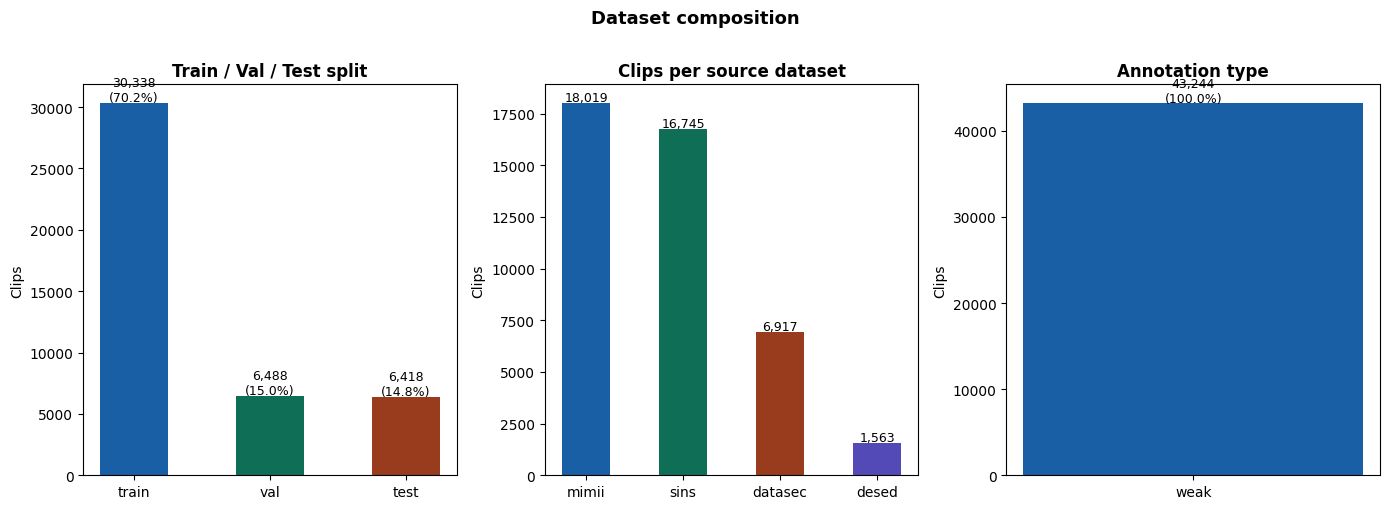

In [ ]:
# ── Plot 2: Split × source breakdown ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 2a — Split distribution
split_counts = df['split'].value_counts().reindex(['train','val','test'])
axes[0].bar(split_counts.index, split_counts.values,
            color=['#185FA5','#0F6E56','#993C1D'], width=0.5)
axes[0].set_title('Train / Val / Test split', fontweight='bold')
axes[0].set_ylabel('Clips')
for i, (v) in enumerate(split_counts.values):
    axes[0].text(i, v + 150, f'{v:,}\n({100*v/len(df):.1f}%)',
                 ha='center', fontsize=9)

# 2b — Source dataset
src_counts = df['source_dataset'].value_counts()
axes[1].bar(src_counts.index, src_counts.values,
            color=['#185FA5','#0F6E56','#993C1D','#534AB7'], width=0.5)
axes[1].set_title('Clips per source dataset', fontweight='bold')
axes[1].set_ylabel('Clips')
for i, v in enumerate(src_counts.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# 2c — Annotation type
annot_counts = df['annotation_type'].value_counts()
axes[2].bar(annot_counts.index, annot_counts.values,
            color=['#185FA5','#993C1D'], width=0.4)
axes[2].set_title('Annotation type', fontweight='bold')
axes[2].set_ylabel('Clips')
for i, v in enumerate(annot_counts.values):
    axes[2].text(i, v + 100, f'{v:,}\n({100*v/len(df):.1f}%)',
                 ha='center', fontsize=9)

plt.suptitle('Dataset composition', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/eda_composition.png', dpi=150, bbox_inches='tight')
plt.show()

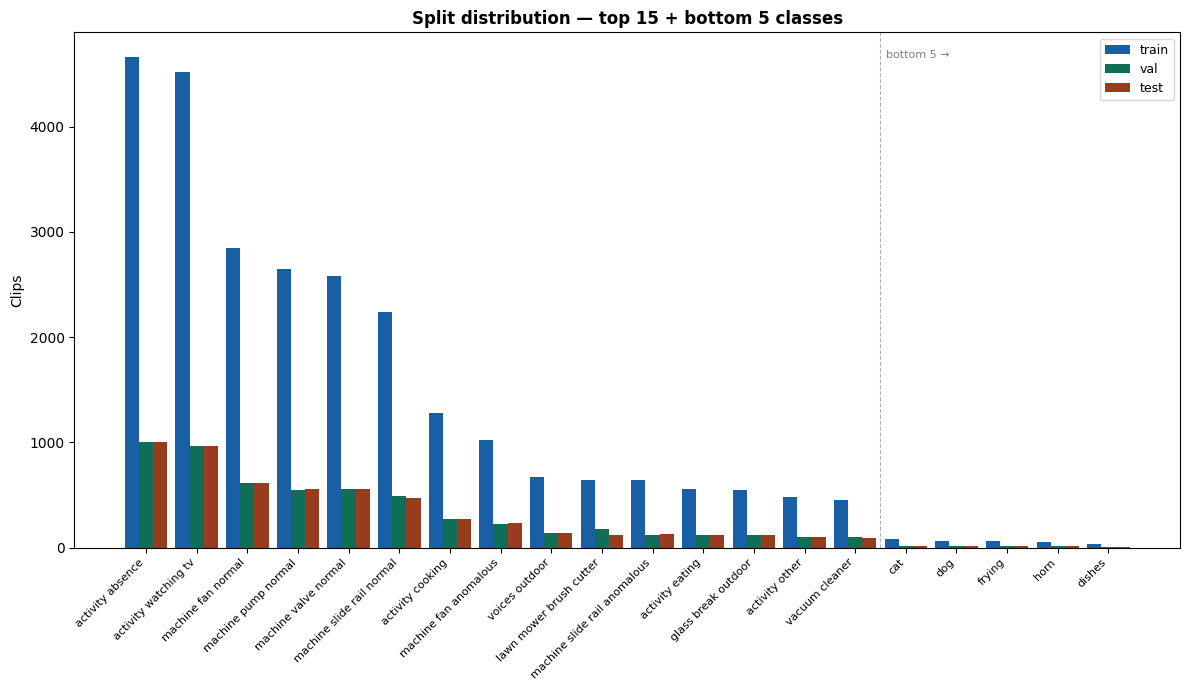

In [ ]:
# ── Plot 3: Class balance per split (top 15 + bottom 5 classes) ──────────
counts  = df['unified_label'].value_counts()   # ← add this line
top15   = counts.head(15).index.tolist()
bot5    = counts.tail(5).index.tolist()
sel_cls = top15 + bot5

pivot = df[df['unified_label'].isin(sel_cls)].groupby(
    ['unified_label','split']).size().unstack(fill_value=0)
pivot = pivot.reindex(sel_cls)

fig, ax = plt.subplots(figsize=(12, 7))
x    = np.arange(len(pivot))
w    = 0.28
ax.bar(x - w,   pivot.get('train', 0), w, label='train', color='#185FA5')
ax.bar(x,       pivot.get('val',   0), w, label='val',   color='#0F6E56')
ax.bar(x + w,   pivot.get('test',  0), w, label='test',  color='#993C1D')

ax.set_xticks(x)
ax.set_xticklabels([l.replace('_',' ') for l in pivot.index],
                   rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Clips')
ax.set_title('Split distribution — top 15 + bottom 5 classes', fontweight='bold')
ax.legend(fontsize=9)
ax.axvline(14.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.text(14.6, ax.get_ylim()[1]*0.95, 'bottom 5 →', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('/kaggle/working/eda_split_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

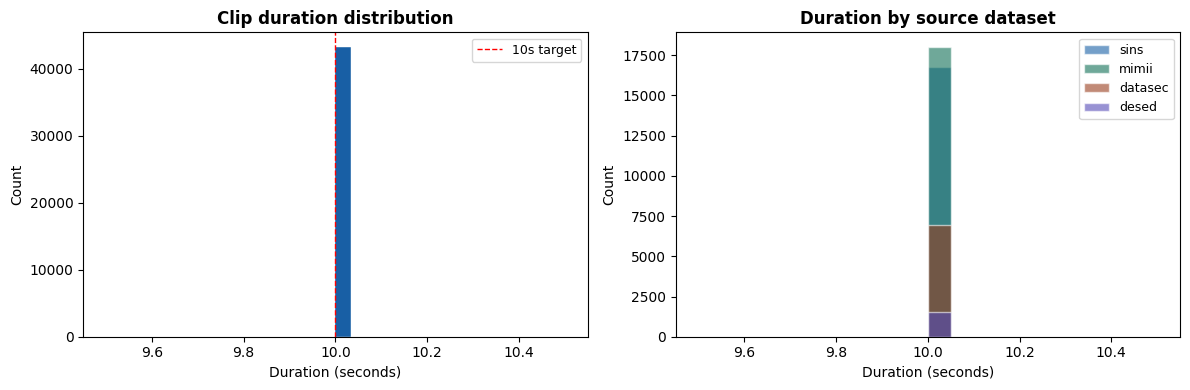

Duration stats:
count    43244.0
mean        10.0
std          0.0
min         10.0
25%         10.0
50%         10.0
75%         10.0
max         10.0
Name: duration, dtype: float64

Clips not exactly 10s: 0


In [ ]:
# ── Plot 4: Duration distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 4a — All clips (should all be 10.0s)
axes[0].hist(df['duration'], bins=30, color='#185FA5', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Count')
axes[0].set_title('Clip duration distribution', fontweight='bold')
axes[0].axvline(10.0, color='red', linestyle='--', linewidth=1, label='10s target')
axes[0].legend(fontsize=9)

# 4b — Duration by source
for src, color in zip(['sins','mimii','datasec','desed'],
                      ['#185FA5','#0F6E56','#993C1D','#534AB7']):
    subset = df[df['source_dataset'] == src]['duration']
    if len(subset):
        axes[1].hist(subset, bins=20, alpha=0.6, color=color, label=src, edgecolor='white')
axes[1].set_xlabel('Duration (seconds)')
axes[1].set_ylabel('Count')
axes[1].set_title('Duration by source dataset', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/eda_duration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Duration stats:')
print(df['duration'].describe().round(3))
print(f'\nClips not exactly 10s: {(df["duration"] != 10.0).sum()}')

  Loaded: speech from 234996.wav
  Loaded: activity_cooking from DevNode1_ex49_53.wav
  Loaded: machine_fan_anomalous from 00000208.wav
  Loaded: jet_aircraft from Jet aircrafts-051_seg001.wav


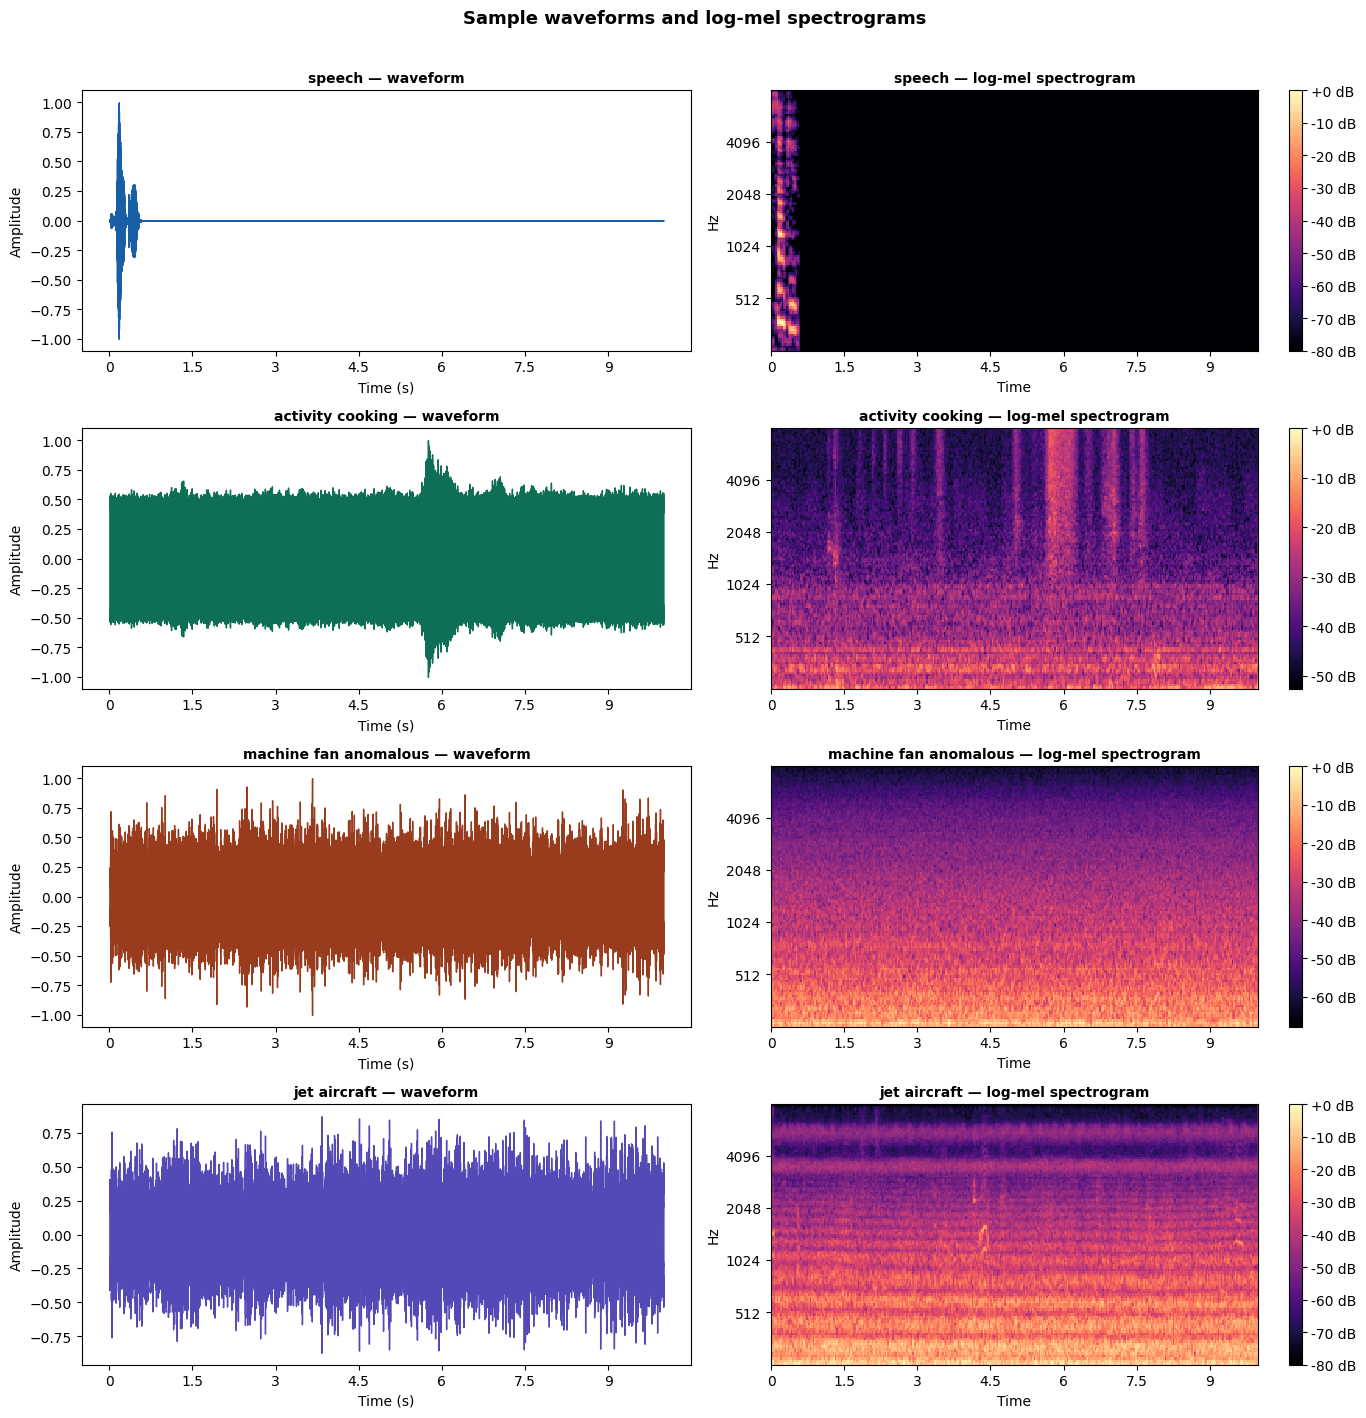

In [ ]:
# ── Plot 5: Waveform + spectrogram samples ────────────────────────────────
import librosa, librosa.display, os, numpy as np, matplotlib.pyplot as plt

DATA_ROOT = '/kaggle/input/datasets/asaavitupsounder/unified-domestic-audio-dataset/content/unified_dataset'

domain_colors = {
    'domestic': '#185FA5',
    'activity': '#0F6E56',
    'anomaly':  '#993C1D',
    'outdoor':  '#534AB7',
}

sample_classes = {
    'domestic': 'speech',
    'activity': 'activity_cooking',
    'anomaly':  'machine_fan_anomalous',
    'outdoor':  'jet_aircraft',
}

def clean_path(raw_path):
    """Strip everything before /audio/ and rebuild from DATA_ROOT."""
    raw = str(raw_path)
    if '/audio/' in raw:
        return DATA_ROOT + '/audio/' + raw.split('/audio/', 1)[1]
    return raw

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
fig.suptitle('Sample waveforms and log-mel spectrograms',
             fontsize=13, fontweight='bold', y=1.01)

for row, (domain, cls) in enumerate(sample_classes.items()):
    subset = df[df['unified_label'] == cls]
    if len(subset) == 0:
        print(f'No clips for: {cls}')
        continue

    loaded = False
    for _, sample_row in subset.sample(min(10, len(subset)), random_state=42).iterrows():
        path = clean_path(sample_row['output_path'])
        if not os.path.exists(path):
            continue
        try:
            y, sr = librosa.load(path, sr=16000, mono=True, duration=10.0)
            if np.max(np.abs(y)) < 1e-6:
                continue
            loaded = True
            break
        except Exception:
            continue

    if not loaded:
        print(f'Could not load any clip for {cls}')
        continue

    color = list(domain_colors.values())[row]

    # Waveform
    ax_w = axes[row][0]
    librosa.display.waveshow(y, sr=sr, ax=ax_w, color=color)
    ax_w.set_title(f'{cls.replace("_"," ")} — waveform', fontsize=10, fontweight='bold')
    ax_w.set_xlabel('Time (s)')
    ax_w.set_ylabel('Amplitude')

    # Log-Mel spectrogram
    ax_s = axes[row][1]
    mel     = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=1024, hop_length=512,
        n_mels=128, fmin=20, fmax=8000)
    log_mel = librosa.power_to_db(mel + 1e-9, ref=np.max)
    img = librosa.display.specshow(
        log_mel, sr=sr, hop_length=512,
        x_axis='time', y_axis='mel',
        fmin=20, fmax=8000, ax=ax_s)
    ax_s.set_title(f'{cls.replace("_"," ")} — log-mel spectrogram',
                   fontsize=10, fontweight='bold')
    fig.colorbar(img, ax=ax_s, format='%+2.0f dB')
    print(f'  Loaded: {cls} from {os.path.basename(path)}')

plt.tight_layout()
plt.savefig('/kaggle/working/eda_samples.png', dpi=150, bbox_inches='tight')
plt.show()

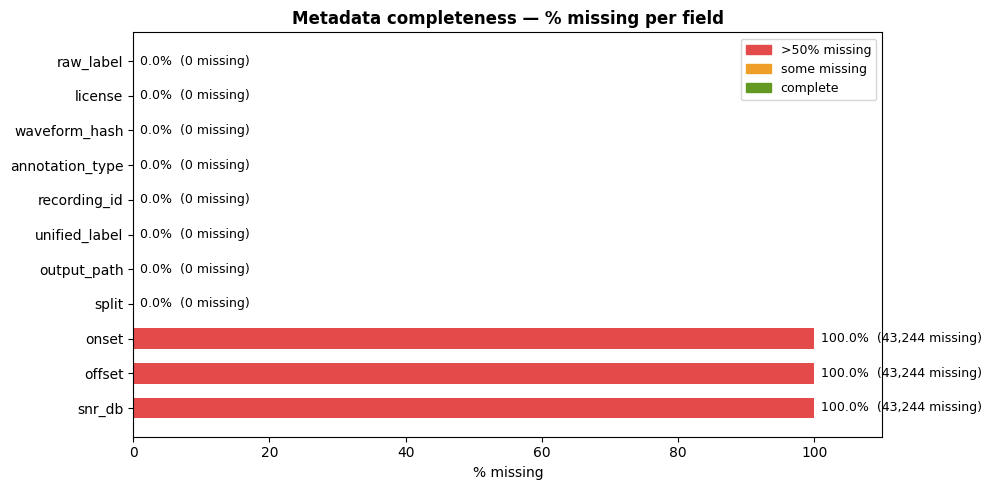


Missingness summary:
          field  missing  pct_missing
         snr_db    43244        100.0
         offset    43244        100.0
          onset    43244        100.0
          split        0          0.0
    output_path        0          0.0
  unified_label        0          0.0
   recording_id        0          0.0
annotation_type        0          0.0
  waveform_hash        0          0.0
        license        0          0.0
      raw_label        0          0.0


In [ ]:
# ── Plot 6: Missingness & metadata completeness ───────────────────────────
fields = ['unified_label', 'output_path', 'split', 'recording_id',
          'waveform_hash', 'annotation_type', 'onset', 'offset',
          'snr_db', 'license', 'raw_label']

miss = pd.DataFrame({
    'field'   : fields,
    'missing' : [df[f].isna().sum() if f in df.columns else len(df) for f in fields],
    'present' : [df[f].notna().sum() if f in df.columns else 0 for f in fields],
})
miss['pct_missing'] = 100 * miss['missing'] / len(df)
miss = miss.sort_values('pct_missing', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_miss = ['#E24B4A' if p > 50 else '#EF9F27' if p > 0 else '#639922'
               for p in miss['pct_missing']]
bars = ax.barh(miss['field'], miss['pct_missing'], color=colors_miss, height=0.6)
ax.set_xlabel('% missing')
ax.set_title('Metadata completeness — % missing per field', fontweight='bold')
ax.set_xlim(0, 110)
for bar, row in zip(bars, miss.itertuples()):
    label = f'{row.pct_missing:.1f}%  ({row.missing:,} missing)'
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=9)

red_p   = mpatches.Patch(color='#E24B4A', label='>50% missing')
amber_p = mpatches.Patch(color='#EF9F27', label='some missing')
green_p = mpatches.Patch(color='#639922', label='complete')
ax.legend(handles=[red_p, amber_p, green_p], fontsize=9)
plt.tight_layout()
plt.savefig('/kaggle/working/eda_missingness.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMissingness summary:')
print(miss[['field','missing','pct_missing']].to_string(index=False))

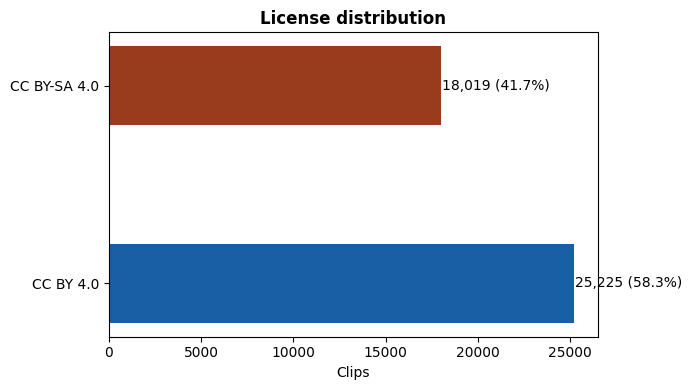

In [ ]:
# ── Plot 7: Licence breakdown ─────────────────────────────────────────────
lic = df['license'].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(lic.index, lic.values, color=['#185FA5','#993C1D'], height=0.4)
ax.set_xlabel('Clips')
ax.set_title('License distribution', fontweight='bold')
for i, v in enumerate(lic.values):
    ax.text(v + 50, i, f'{v:,} ({100*v/len(df):.1f}%)', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('/kaggle/working/eda_license.png', dpi=150, bbox_inches='tight')
plt.show()

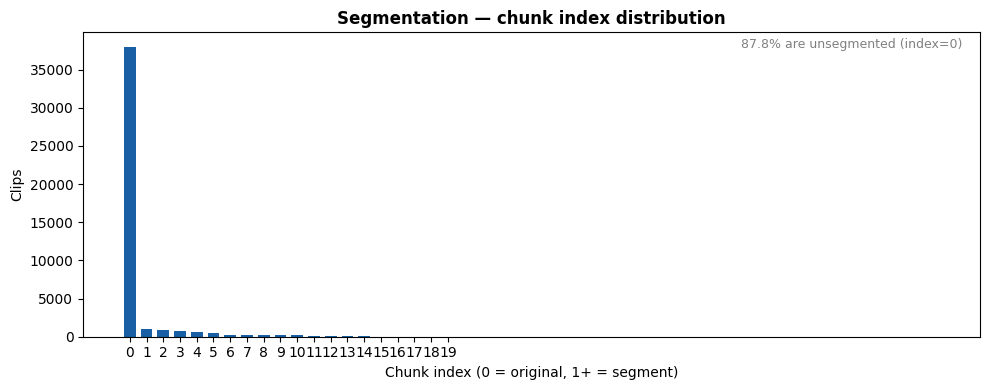

In [ ]:
# ── Plot 8: Chunk index distribution (segmentation analysis) ──────────────
if 'chunk_index' in df.columns:
    chunk_counts = df['chunk_index'].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(chunk_counts.index, chunk_counts.values, color='#185FA5', width=0.7)
    ax.set_xlabel('Chunk index (0 = original, 1+ = segment)')
    ax.set_ylabel('Clips')
    ax.set_title('Segmentation — chunk index distribution', fontweight='bold')
    ax.set_xticks(range(min(20, len(chunk_counts))))
    pct_original = 100 * chunk_counts.get(0, 0) / len(df)
    ax.text(0.98, 0.95, f'{pct_original:.1f}% are unsegmented (index=0)',
            transform=ax.transAxes, ha='right', fontsize=9, color='gray')
    plt.tight_layout()
    plt.savefig('/kaggle/working/eda_chunks.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# ── Summary printout ──────────────────────────────────────────────────────
print('='*55)
print('  EDA SUMMARY')
print('='*55)
print(f'  Total clips         : {len(df):,}')
print(f'  Total duration      : {df["duration"].sum()/3600:.1f} hours')
print(f'  Classes             : {df["unified_label"].nunique()}')
print(f'  Imbalance ratio     : {counts.max()/counts.min():.0f}x')
print(f'  Weak annotations    : {(df["annotation_type"]=="weak").sum():,} ({100*(df["annotation_type"]=="weak").mean():.1f}%)')
print(f'  Strong annotations  : {(df["annotation_type"]=="strong").sum():,} ({100*(df["annotation_type"]=="strong").mean():.1f}%)')
print(f'  onset/offset missing: {df["onset"].isna().sum():,} ({100*df["onset"].isna().mean():.1f}%)')
print(f'  snr_db available    : {df["snr_db"].notna().sum():,} clips (MIMII only)')
print(f'  Duplicate hashes    : {df["waveform_hash"].duplicated().sum()}')
print('='*55)
print('\nAll EDA plots saved to /kaggle/working/')

  EDA SUMMARY
  Total clips         : 43,244
  Total duration      : 120.1 hours
  Classes             : 40
  Imbalance ratio     : 139x
  Weak annotations    : 43,244 (100.0%)
  Strong annotations  : 0 (0.0%)
  onset/offset missing: 43,244 (100.0%)
  snr_db available    : 0 clips (MIMII only)
  Duplicate hashes    : 0

All EDA plots saved to /kaggle/working/
